In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import tensorflow as tf
from collections import deque
import random


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"



In [ ]:
# Load the .npz file
loaded_data = np.load("cnn_results_combined.npz")
true_labels = loaded_data['true_labels']
softmax_outputs = loaded_data['softmax_outputs']
predicted_labels = loaded_data['predicted_labels']

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# === Setup ===
known_labels = np.arange(6)
unknown_label = 6

# Get all known and unknown indices
known_indices = np.where(np.isin(true_labels, known_labels))[0]
unknown_indices = np.where(true_labels == unknown_label)[0]

# Calculate validation set size as 10% of total dataset
total_size = len(true_labels)
val_size = int(0.1* total_size)

# For a balanced val set, half known and half unknown
val_half_size = val_size // 2

# Ensure we have enough samples
assert len(known_indices) >= val_half_size, "Not enough known samples for validation"
assert len(unknown_indices) >= val_half_size, "Not enough unknown samples for validation"

# Select samples for validation
val_known_indices = known_indices[:val_half_size]
val_unknown_indices = unknown_indices[:val_half_size]
val_indices = np.concatenate([val_known_indices, val_unknown_indices])

# Everything else goes to test set
remaining_indices = np.setdiff1d(np.arange(total_size), val_indices)

# === Sanity Check ===
print("=== Set Sizes ===")
print(f"Validation Set: {len(val_indices)} (Known: {len(val_known_indices)}, Unknown: {len(val_unknown_indices)})")
print(f"Test Set:       {len(remaining_indices)}")

test_known = np.sum(true_labels[remaining_indices] != unknown_label)
test_unknown = np.sum(true_labels[remaining_indices] == unknown_label)

print("\n=== Balance Check ===")
print(f"Test Known:      {test_known}")
print(f"Test Unknown:    {test_unknown}")


=== Set Sizes ===
Validation Set: 798 (Known: 399, Unknown: 399)
Test Set:       7201

=== Balance Check ===
Test Known:      5918
Test Unknown:    1283


In [ ]:
def compute_entropy(softmax_outputs):
    """
    Compute the entropy of softmax probability distributions.

    Parameters:
        softmax_outputs (np.ndarray): Softmax output array of shape (n_samples, n_classes)

    Returns:
        np.ndarray: Entropy values of shape (n_samples,)
    """
    epsilon = 1e-12  # to avoid log(0)
    softmax_clipped = np.clip(softmax_outputs, epsilon, 1. - epsilon)
    entropy = -np.sum(softmax_clipped * np.log(softmax_clipped), axis=1)
    return entropy

# === Compute Entropy ===
val_softmax_outputs = softmax_outputs[val_indices]
test_softmax_outputs = softmax_outputs[remaining_indices]

val_entropy = compute_entropy(val_softmax_outputs)
test_entropy = compute_entropy(test_softmax_outputs)

# === Stats Check ===
print(f"Validation entropy stats - min: {val_entropy.min():.4f}, max: {val_entropy.max():.4f}, mean: {val_entropy.mean():.4f}")
print(f"Test entropy stats       - min: {test_entropy.min():.4f}, max: {test_entropy.max():.4f}, mean: {test_entropy.mean():.4f}")


Validation entropy stats - min: 0.0000, max: 1.3835, mean: 0.3720
Test entropy stats       - min: 0.0000, max: 1.4699, mean: 0.3675


In [ ]:
from scipy.stats import entropy

def compute_entropy(softmax_probs):

    epsilon = 1e-12
    softmax_clipped = np.clip(softmax_probs, epsilon, 1. - epsilon)
    return entropy(softmax_clipped.T)  # entropy across classes for each sample

# === Extract softmax outputs for validation set ===
val_softmax_outputs = softmax_outputs[val_indices]  # shape: (n_val_samples, n_classes)

# === Compute p1 (max confidence), p1 - p2, and entropy ===
val_p1 = np.max(val_softmax_outputs, axis=1)
sorted_preds = np.sort(val_softmax_outputs, axis=1)
val_p1_p2_diff = sorted_preds[:, -1] - sorted_preds[:, -2]
val_entropy = compute_entropy(val_softmax_outputs)

# === Define top/bottom 5% size ===
n_val = len(val_indices)
n_top_bottom = int(0.05 * n_val)

# === Get top 5% high-confidence based on p1 only ===
sorted_indices = np.argsort(val_p1)
low_conf_top_indices = sorted_indices[:n_top_bottom]        # bottom 5% → low confidence
high_conf_top_indices = sorted_indices[-n_top_bottom:]      # top 5% → high confidence

# === Create boolean masks (for excluding in training) ===
high_conf_mask = np.zeros(n_val, dtype=bool)
low_conf_mask = np.zeros(n_val, dtype=bool)
high_conf_mask[high_conf_top_indices] = True
low_conf_mask[low_conf_top_indices] = True

# === Optional Debug Output ===
print(f"High-confidence samples selected: {len(high_conf_top_indices)}")
print(f"Low-confidence samples selected:  {len(low_conf_top_indices)}")
print(f"Mean p1: {np.mean(val_p1):.4f}")
print(f"Mean p1-p2 diff: {np.mean(val_p1_p2_diff):.4f}")
print(f"Mean entropy: {np.mean(val_entropy):.4f}")


High-confidence samples selected: 39
Low-confidence samples selected:  39
Mean p1: 0.8813
Mean p1-p2 diff: 0.7996
Mean entropy: 0.3720


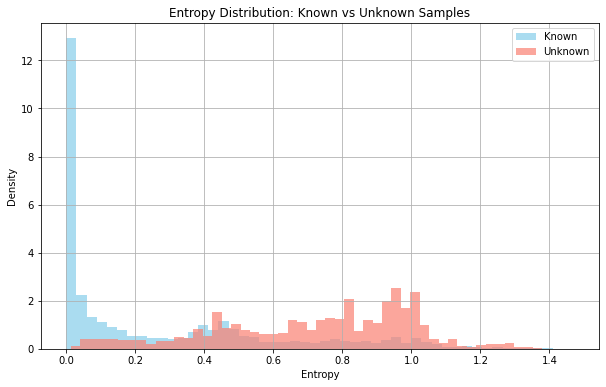

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import entropy


# --- Step 1: Compute entropy for each sample ---
entropies = entropy(softmax_outputs, axis=1)

# --- Step 2: Separate entropy of known vs unknown ---
known_mask = np.isin(true_labels, known_labels)
unknown_mask = ~known_mask

known_entropies = entropies[known_mask]
unknown_entropies = entropies[unknown_mask]

# --- Step 3: Plot the distributions ---
plt.figure(figsize=(10, 6))
plt.hist(known_entropies, bins=50, alpha=0.7, label='Known', color='skyblue', density=True)
plt.hist(unknown_entropies, bins=50, alpha=0.7, label='Unknown', color='salmon', density=True)
plt.title('Entropy Distribution: Known vs Unknown Samples')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


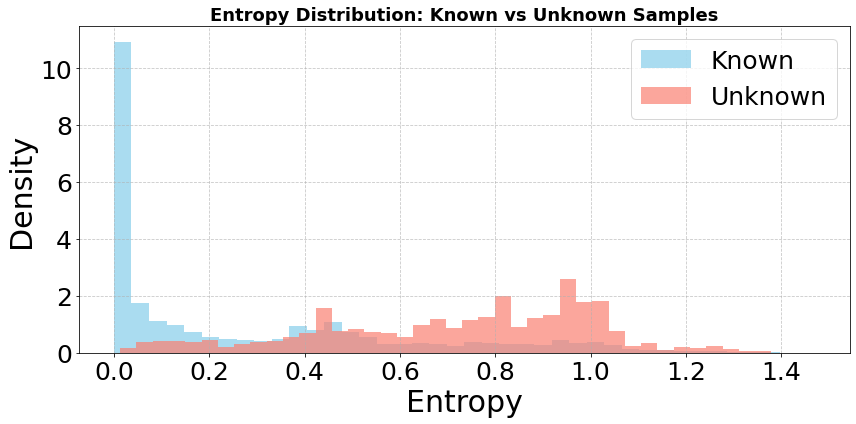

In [ ]:
# --- Step 3: Plot the distributions with improved readability ---
plt.figure(figsize=(12, 6))

plt.hist(known_entropies, bins=40, alpha=0.7, label='Known', color='skyblue', density=True)
plt.hist(unknown_entropies, bins=40, alpha=0.7, label='Unknown', color='salmon', density=True)

# Title and axis labels
plt.title('Entropy Distribution: Known vs Unknown Samples', fontsize=18, fontweight='bold')
plt.xlabel('Entropy', fontsize=30)
plt.ylabel('Density', fontsize=30)

# Legend and ticks
plt.legend(fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Grid styling
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

class DQNAgent:
    def __init__(self, state_size=3, action_size=2):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.990
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(self.state_size,)),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate), loss='mse')
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randint(0, self.action_size - 1)
        q_values = self.model.predict(state, verbose=0)
        return np.argmax(q_values[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                target += self.gamma * np.amax(self.model.predict(next_state, verbose=0)[0])
            q_values = self.model.predict(state, verbose=0)
            q_values[0][action] = target
            self.model.fit(state, q_values, epochs=1, verbose=0)
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# === Initialization ===
agent = DQNAgent(state_size=3, action_size=2)
batch_size = 32
episodes = 30

val_pred_confidence = np.zeros(n_val, dtype=int)

# Initial centroids from top/bottom 5% p1 confidence
high_conf_list = list(high_conf_top_indices)
low_conf_list = list(low_conf_top_indices)

centroid_high = np.array([
    np.mean(val_p1[high_conf_list]),
    np.mean(val_p1_p2_diff[high_conf_list]),
    np.mean(val_entropy[high_conf_list])
])
centroid_low = np.array([
    np.mean(val_p1[low_conf_list]),
    np.mean(val_p1_p2_diff[low_conf_list]),
    np.mean(val_entropy[low_conf_list])
])
high_count = len(high_conf_list)
low_count = len(low_conf_list)

# Remaining samples (excluding anchors)
rest_indices = np.where(~high_conf_mask & ~low_conf_mask)[0]
np.random.shuffle(rest_indices)
subsample_size = min(1500, len(rest_indices))
rest_indices = rest_indices[:subsample_size]

# === Training Loop ===
for episode in range(episodes):
    total_reward = 0
    n_processed = 0
    action_stats = {0: 0, 1: 0}

    for i, idx in enumerate(rest_indices):
        state = np.array([val_p1[idx], val_p1_p2_diff[idx], val_entropy[idx]]).reshape(1, -1)
        action = agent.act(state)
        action_stats[action] += 1

        # Compute similarity to both centroids
        sim_high = cosine_similarity(state, centroid_high.reshape(1, -1))[0][0]
        sim_low = cosine_similarity(state, centroid_low.reshape(1, -1))[0][0]

        # Reward = similarity to closest match, penalty otherwise
        reward_magnitude = max(sim_high, sim_low)
        best_action = 1 if sim_high > sim_low else 0
        reward = reward_magnitude if action == best_action else -reward_magnitude
        reward = np.clip(reward, -1.0, 1.0)

        total_reward += reward
        n_processed += 1
        val_pred_confidence[idx] = action

        # Only update centroid if similarity is strong (prevents noise)
        similarity_threshold = 0.75
        if action == 1 and sim_high > similarity_threshold:
            centroid_high = (centroid_high * high_count + state.flatten()) / (high_count + 1)
            high_count += 1
        elif action == 0 and sim_low > similarity_threshold:
            centroid_low = (centroid_low * low_count + state.flatten()) / (low_count + 1)
            low_count += 1

        # Next state for replay buffer
        next_idx = random.choice(rest_indices)
        next_state = np.array([val_p1[next_idx], val_p1_p2_diff[next_idx], val_entropy[next_idx]]).reshape(1, -1)
        done = (i == len(rest_indices) - 1)
        agent.remember(state, action, reward, next_state, done)

    # Train from memory
    agent.replay(batch_size)

    # === Logging ===
    avg_reward = total_reward / n_processed
    print(f"\n--- Episode {episode + 1}/{episodes} ---")
    print(f"Avg Reward: {avg_reward:.4f} | ε: {agent.epsilon:.4f}")
    print(f"High Conf Count: {high_count} | Low Conf Count: {low_count}")
    print(f"Actions → High: {action_stats[1]}, Low: {action_stats[0]}")
    print(f"Centroid High: {centroid_high}")



--- Episode 1/30 ---
Avg Reward: 0.0830 | ε: 0.9900
High Conf Count: 406 | Low Conf Count: 290
Actions → High: 375, Low: 345
Centroid High: [0.91591537 0.8588887  0.30076864]

--- Episode 2/30 ---
Avg Reward: -0.0026 | ε: 0.9801
High Conf Count: 768 | Low Conf Count: 641
Actions → High: 369, Low: 351
Centroid High: [0.90897363 0.8467242  0.32236317]

--- Episode 3/30 ---
Avg Reward: 0.0686 | ε: 0.9703
High Conf Count: 1141 | Low Conf Count: 985
Actions → High: 376, Low: 344
Centroid High: [0.9087047  0.84616196 0.3233323 ]

--- Episode 4/30 ---
Avg Reward: 0.0022 | ε: 0.9606
High Conf Count: 1489 | Low Conf Count: 1351
Actions → High: 354, Low: 366
Centroid High: [0.9072786  0.84380597 0.3280673 ]

--- Episode 5/30 ---
Avg Reward: 0.0031 | ε: 0.9510
High Conf Count: 1862 | Low Conf Count: 1691
Actions → High: 378, Low: 342
Centroid High: [0.90623033 0.842124   0.33159113]

--- Episode 6/30 ---
Avg Reward: 0.0423 | ε: 0.9415
High Conf Count: 2215 | Low Conf Count: 2054
Actions → High: 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import entropy  # import properly

# === Compute entropy function ===
def compute_entropy(softmax_probs):
    epsilon = 1e-12
    softmax_clipped = np.clip(softmax_probs, epsilon, 1. - epsilon)
    return entropy(softmax_clipped.T)  # entropy for each sample

# === Extract test features consistent with training ===
test_p1 = np.max(test_softmax_outputs, axis=1)
sorted_test_preds = np.sort(test_softmax_outputs, axis=1)
test_p1_p2_diff = sorted_test_preds[:, -1] - sorted_test_preds[:, -2]
test_entropy = compute_entropy(test_softmax_outputs)

# Stack features for DQN
test_features = np.stack([test_p1, test_p1_p2_diff, test_entropy], axis=1)

# Predict confidence (action 0 or 1) using trained DQN model
dqn_predictions = agent.model.predict(test_features, verbose=0)
predicted_actions = np.argmax(dqn_predictions, axis=1)  # 0 = unknown, 1 = known

# Prepare true binary confidence labels:
# 6 known classes (0–5), 1 unknown class (6)
known_labels = np.arange(6)
test_true_labels = true_labels[remaining_indices]
true_confidence = np.isin(test_true_labels, known_labels).astype(int)

# Evaluate performance
accuracy = accuracy_score(true_confidence, predicted_actions)
f1 = f1_score(true_confidence, predicted_actions)

# Correct predictions for known and unknown separately
correct_known = np.sum((predicted_actions == 1) & (true_confidence == 1))
total_known = np.sum(true_confidence == 1)

correct_unknown = np.sum((predicted_actions == 0) & (true_confidence == 0))
total_unknown = np.sum(true_confidence == 0)

print("=== Test Set Confidence Prediction ===")
print(f"Total samples: {len(test_true_labels)}")
print(f"Known samples: {total_known}")
print(f"Unknown samples: {total_unknown}")
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall F1 Score: {f1:.4f}")
print(f"Correct Known predictions: {correct_known} / {total_known}")
print(f"Correct Unknown predictions: {correct_unknown} / {total_unknown}")



=== Test Set Confidence Prediction ===
Total samples: 7201
Known samples: 5918
Unknown samples: 1283
Overall Accuracy: 0.7489
Overall F1 Score: 0.8247
Correct Known predictions: 4253 / 5918
Correct Unknown predictions: 1140 / 1283


#Evaluation of CNN-DQN

In [ ]:
from collections import Counter


# known_labels indices
known_labels = np.arange(5)  # Known classes are 0 to 9 inclusive

# Filter indices for known class samples in the test set
known_indices = np.where(np.isin(true_labels, known_labels))[0]

# Extract relevant arrays for known samples
true_known_labels = true_labels[known_indices]
cnn_pred_known_labels = predicted_labels[known_indices]
dqn_pred_known_confidence = predicted_actions[known_indices]  # 1 means "known" predicted by DQN


In [ ]:
print("\n=== CNN Predictions Breakdown for Known Classes ===")
for cls in known_labels:
    cls_mask = (true_known_labels == cls)
    pred_counts = Counter(cnn_pred_known_labels[cls_mask])
    print(f"True class {cls}: CNN predicted counts: {dict(pred_counts)}")



=== CNN Predictions Breakdown for Known Classes ===
True class 0: CNN predicted counts: {2: 105, 0: 495, 1: 148, 5: 67, 3: 3}
True class 1: CNN predicted counts: {1: 658, 2: 126, 5: 139, 0: 276, 3: 1}
True class 2: CNN predicted counts: {2: 993, 5: 62, 0: 109, 3: 19, 1: 16, 4: 1}
True class 3: CNN predicted counts: {3: 1163, 0: 7, 1: 15, 2: 13, 5: 2}
True class 4: CNN predicted counts: {4: 1196, 0: 1, 2: 2, 3: 1}
